# 222 — Synteny: where in the target genome do the MHC's hits land?

**Question:** the midi run scores each hit as a domain call and never looks at where the
target protein lives. If those hits are recovering real orthologs, the human MHC's hits
should not be scattered across the target genome — they should pile up in one place, and
that place should be the target's own MHC.

**What this notebook is for.** It is not a kmerseek result. Sections 1 to 3 are phmmer
best-hit throughout; kmerseek appears in §4 as one arm among several. The job here is a
validity check on the machinery that everything else in the 220–226 block rests on: if the
domain-call pipeline recovers real, specific, lineage-particular biology — the mouse H2
complex, the chicken minimal essential MHC, and the teleost class I / class II split — then
its outputs can be trusted far enough to argue about what its *metric* is doing. That is
what licenses [223](./223_mhc_platform_vs_ig_domain.ipynb)'s critique of the IoU rule and
[221](./221_mhc_cross_species_detection_depth.ipynb)'s recomputation under cover. A reviewer
who wants to dismiss 223 as special pleading has to first explain how a broken pipeline
reproduced all three of those facts without being told any of them.

This is a stronger test than a recall number, because nothing in the pipeline knows about
genomic position. Chromosome coordinates are joined on afterwards, from Ensembl 116, using
gene symbols UniProt had already assigned. If the block appears, it was not put there.

Scope is mouse, chicken and zebrafish. That is not laziness:
[221](./221_mhc_cross_species_detection_depth.ipynb) shows no MHC molecule is detected in
any target past zebrafish, so there is no block further out to find.

**Raw percentages are not readable here, so none are quoted on their own.** Chicken
chromosome 16 is a microchromosome; zebrafish chromosome 19 is one of 25. A hit rate of 25%
on a chromosome holding 0.2% of the placeable proteome is a much larger result than 71% on
one holding 4.9%. Every species below is reported as **observed over expected**, against the
chromosome's own share of the placeable target proteins, with a p-value and an n.

Neither this notebook nor 221 reads `recall_reachable` or `n_reachable_instances` from the
pipeline's summary metrics. Every denominator here is built from `target_locus_table` and the
run's own region tables.

Best phmmer hit per MHC-window query, tested against the expected MHC chromosome:
shape: (3, 15)
┌───────────┬───────┬─────┬─────────────┬───┬────────────────────┬─────────────────────┬─────────────────────┬───────────────────┐
│ species   ┆ chrom ┆ mya ┆ n_placeable ┆ … ┆ n_distinct_targets ┆ n_distinct_on_chrom ┆ enrichment_distinct ┆ log10_p_hypergeom │
│ ---       ┆ ---   ┆ --- ┆ ---         ┆   ┆ ---                ┆ ---                 ┆ ---                 ┆ ---               │
│ str       ┆ str   ┆ i64 ┆ i64         ┆   ┆ i64                ┆ i64                 ┆ f64                 ┆ f64               │
╞═══════════╪═══════╪═════╪═════════════╪═══╪════════════════════╪═════════════════════╪═════════════════════╪═══════════════════╡
│ mouse     ┆ 17    ┆ 100 ┆ 19297       ┆ … ┆ 152                ┆ 115                 ┆ 15.5                ┆ -119.2            │
│ chicken   ┆ 16    ┆ 300 ┆ 13141       ┆ … ┆ 76                 ┆ 9                   ┆ 59.9                ┆ -13.9 

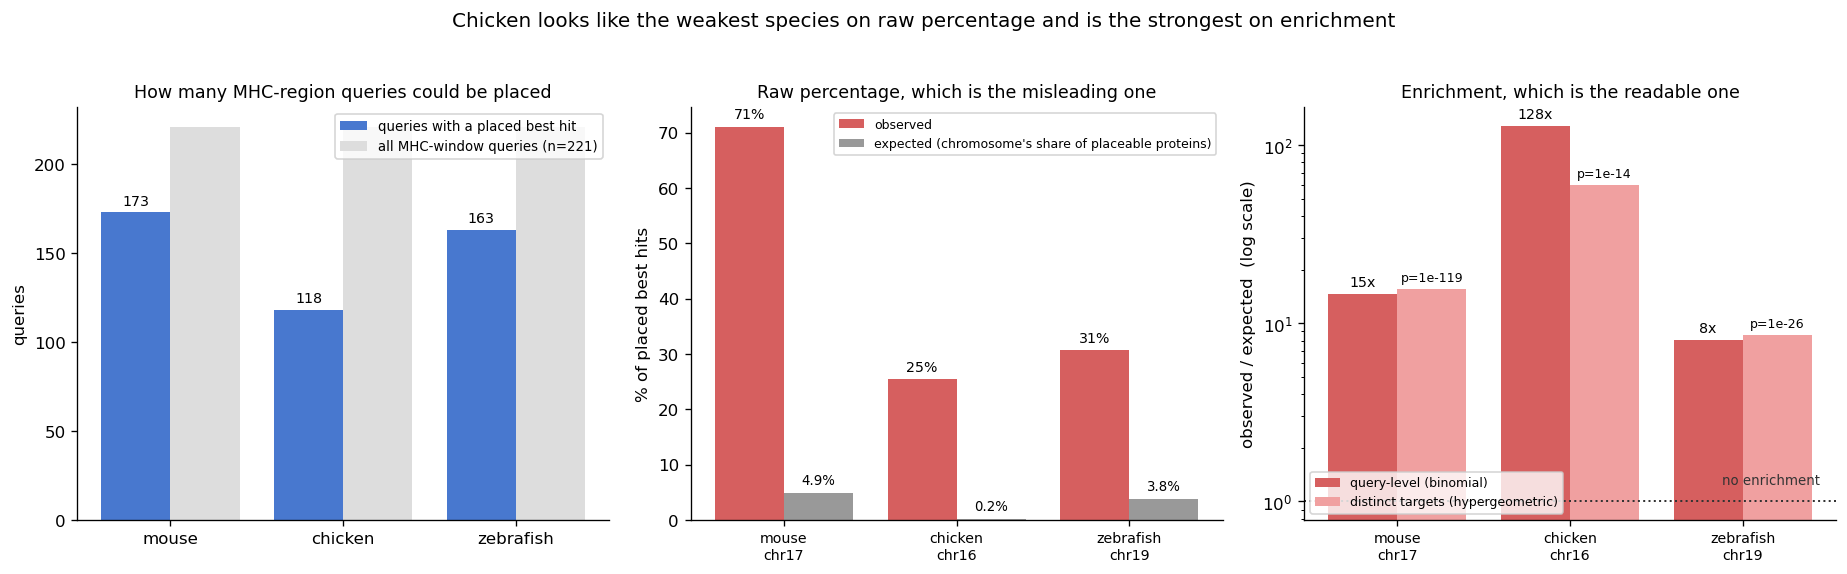

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from scipy.stats import binom, hypergeom, spearmanr

import mhc_region_utils as mu

FIG_DIR = Path("../figures")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight", "font.size": 10})

gene_map = mu.load_chr6_gene_map()
window = mu.load_mhc_window(gene_map)
core = gene_map.filter(pl.col("mhc_class").is_not_null())
SPECIES = list(mu.ENSEMBL_SPECIES)

HUMAN = window.select(
    query_acc="accession",
    hgnc_symbol="hgnc_symbol",
    mhc_subregion="mhc_subregion",
    human_pos="midpoint",
)
CORE = core.select(query_acc="accession", mhc_class="mhc_class")
LOCI = {sp: mu.target_locus_table(sp) for sp in SPECIES}


def best_baseline_hits(species, tool="hmmer3_phmmer", per_query=1):
    # Rank a tool's hits for each query by e-value and keep the top `per_query`. "Best hit"
    # is a crude ortholog proxy -- it is not reciprocal and it has no synteny input -- which
    # is exactly why it is used here: any block that shows up did so without help.
    hits = (
        pl.scan_parquet(mu.BASELINE_REGIONS)
        .filter((pl.col("species") == species) & (pl.col("tool") == tool))
        .select("query_acc", "target_acc", "evalue")
        .collect()
    )
    return (
        hits.sort("evalue")
        .group_by("query_acc")
        .head(per_query)
        .join(LOCI[species], on="target_acc", how="inner")
        .join(HUMAN, on="query_acc", how="inner")
    )


placed = {sp: best_baseline_hits(sp) for sp in SPECIES}


def chrom_null(species):
    # The null a best hit could actually land on: the share of PLACEABLE target proteins
    # carried by each chromosome. An unplaceable protein is not in the sample space, so it
    # must not be in the denominator either.
    loci = LOCI[species]
    return (
        loci.group_by("chrom")
        .len()
        .rename({"len": "n_proteins"})
        .with_columns(share=pl.col("n_proteins") / loci.height)
    )


def enrichment(hit_frame, species, chrom):
    # Two null models, because the data supports two questions and only one of them is a
    # hypergeometric.
    #   query-level : each of n queries independently picks a best-hit protein. Sampling is
    #                 WITH replacement (several queries can pick the same target), so the
    #                 tail probability is binomial.
    #   protein-level: how many DISTINCT target proteins were hit, and how many of those sit
    #                 on the chromosome. Sampling without replacement, so hypergeometric.
    loci = LOCI[species]
    N = loci.height
    K = loci.filter(pl.col("chrom") == chrom).height
    share = K / N
    n = hit_frame.height
    x = hit_frame.filter(pl.col("chrom") == chrom).height
    d = hit_frame.unique(subset="target_acc")
    nd = d.height
    xd = d.filter(pl.col("chrom") == chrom).height
    return {
        "species": species,
        "chrom": chrom,
        "mya": mu.SPECIES_MYA[species],
        "n_placeable": N,
        "n_on_chrom": K,
        "expected_share": share,
        "n_hits": n,
        "n_hits_on_chrom": x,
        "obs_share": x / n if n else None,
        "enrichment": (x / n) / share if n and share else None,
        "log10_p_binom": (
            float(binom.logsf(x - 1, n, share) / np.log(10)) if n else None
        ),
        "n_distinct_targets": nd,
        "n_distinct_on_chrom": xd,
        "enrichment_distinct": (xd / nd) / share if nd and share else None,
        "log10_p_hypergeom": (
            float(hypergeom.logsf(xd - 1, N, K, nd) / np.log(10)) if nd else None
        ),
    }


rows = [enrichment(placed[sp], sp, mu.MHC_LOCUS[sp][0]) for sp in SPECIES]
enr = pl.DataFrame(rows)
print(
    "Best phmmer hit per MHC-window query, tested against the expected MHC chromosome:"
)
with pl.Config(tbl_width_chars=230, tbl_rows=12):
    print(
        enr.with_columns(
            expected_share=pl.col("expected_share").round(5),
            obs_share=pl.col("obs_share").round(3),
            enrichment=pl.col("enrichment").round(1),
            enrichment_distinct=pl.col("enrichment_distinct").round(1),
            log10_p_binom=pl.col("log10_p_binom").round(1),
            log10_p_hypergeom=pl.col("log10_p_hypergeom").round(1),
        )
    )
for r in enr.iter_rows(named=True):
    print(
        f"{r['species']:10s} chr{r['chrom']:<3s} "
        f"{r['n_hits_on_chrom']:3d}/{r['n_hits']:3d} hits = {100 * r['obs_share']:4.1f}%  "
        f"vs {100 * r['expected_share']:5.2f}% expected  ->  "
        f"{r['enrichment']:6.1f}x  (binomial p = 1e{r['log10_p_binom']:.0f});  "
        f"distinct targets {r['n_distinct_on_chrom']:3d}/{r['n_distinct_targets']:3d} = "
        f"{r['enrichment_distinct']:5.1f}x  (hypergeometric p = 1e{r['log10_p_hypergeom']:.0f})"
    )

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))
x = np.arange(len(SPECIES))
ax = axes[0]
ax.bar(
    x - 0.2, enr["n_hits"], 0.4, color="#4878CF", label="queries with a placed best hit"
)
ax.bar(
    x + 0.2,
    [window.height] * len(SPECIES),
    0.4,
    color="#dddddd",
    zorder=0,
    label=f"all MHC-window queries (n={window.height})",
)
for i, r in enumerate(enr.iter_rows(named=True)):
    ax.text(i - 0.2, r["n_hits"] + 4, str(r["n_hits"]), ha="center", fontsize=8.5)
ax.set_xticks(x)
ax.set_xticklabels(SPECIES)
ax.set_ylabel("queries")
ax.set_title("How many MHC-region queries could be placed", fontsize=10.5)
ax.legend(fontsize=8)

ax = axes[1]
ax.bar(x - 0.2, 100 * enr["obs_share"], 0.4, color="#D65F5F", label="observed")
ax.bar(
    x + 0.2,
    100 * enr["expected_share"],
    0.4,
    color="#999999",
    label="expected (chromosome's share of placeable proteins)",
)
for i, r in enumerate(enr.iter_rows(named=True)):
    ax.text(
        i - 0.2,
        100 * r["obs_share"] + 1.5,
        f"{100 * r['obs_share']:.0f}%",
        ha="center",
        fontsize=8.5,
    )
    ax.text(
        i + 0.2,
        100 * r["expected_share"] + 1.5,
        f"{100 * r['expected_share']:.1f}%",
        ha="center",
        fontsize=8,
    )
ax.set_xticks(x)
ax.set_xticklabels([f"{sp}\nchr{mu.MHC_LOCUS[sp][0]}" for sp in SPECIES], fontsize=8.5)
ax.set_ylabel("% of placed best hits")
ax.set_title("Raw percentage, which is the misleading one", fontsize=10.5)
ax.legend(fontsize=7.5)

ax = axes[2]
ax.bar(x - 0.2, enr["enrichment"], 0.4, color="#D65F5F", label="query-level (binomial)")
ax.bar(
    x + 0.2,
    enr["enrichment_distinct"],
    0.4,
    color="#F0A0A0",
    label="distinct targets (hypergeometric)",
)
ax.axhline(1.0, color="#333333", lw=1.2, ls=":")
ax.text(
    len(SPECIES) - 0.55, 1.25, "no enrichment", ha="right", fontsize=8, color="#333333"
)
for i, r in enumerate(enr.iter_rows(named=True)):
    ax.text(
        i - 0.2,
        r["enrichment"] * 1.1,
        f"{r['enrichment']:.0f}x",
        ha="center",
        fontsize=8.5,
    )
    ax.text(
        i + 0.2,
        r["enrichment_distinct"] * 1.1,
        f"p=1e{r['log10_p_hypergeom']:.0f}",
        ha="center",
        fontsize=7.5,
    )
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([f"{sp}\nchr{mu.MHC_LOCUS[sp][0]}" for sp in SPECIES], fontsize=8.5)
ax.set_ylabel("observed / expected  (log scale)")
ax.set_title("Enrichment, which is the readable one", fontsize=10.5)
ax.legend(fontsize=7.5, loc="lower left")
for a_ in axes:
    for s_ in ("right", "top"):
        a_.spines[s_].set_visible(False)
fig.suptitle(
    "Chicken looks like the weakest species on raw percentage and is the strongest "
    "on enrichment",
    y=1.03,
)
fig.tight_layout()
fig.savefig(FIG_DIR / "222_placement_summary.png", dpi=200)

## 1. Every MHC-region gene, and the target chromosome its best hit lands on

One dot per human query: x is its position on human chr6, y is the target chromosome its
best hit falls on. Colour is the xMHC sub-region from notebook 220.

The bar chart beside each panel is the same data as enrichment per chromosome, so a
microchromosome carrying a handful of genes is not buried under a large chromosome that
collected more hits simply by being large.

Top target chromosomes per species, with the chromosome's own share as the null:

mouse  (expected chr17, H2 complex)
shape: (5, 7)
┌───────┬────────────┬────────┬────────┬───────────┬────────────┬────────┐
│ chrom ┆ n_proteins ┆ share  ┆ n_hits ┆ obs_share ┆ enrichment ┆ is_mhc │
│ ---   ┆ ---        ┆ ---    ┆ ---    ┆ ---       ┆ ---        ┆ ---    │
│ str   ┆ u32        ┆ f64    ┆ u32    ┆ f64       ┆ f64        ┆ bool   │
╞═══════╪════════════╪════════╪════════╪═══════════╪════════════╪════════╡
│ 17    ┆ 939        ┆ 0.0487 ┆ 123    ┆ 0.711     ┆ 14.6       ┆ true   │
│ 13    ┆ 715        ┆ 0.0371 ┆ 41     ┆ 0.237     ┆ 6.4        ┆ false  │
│ 4     ┆ 1162       ┆ 0.0602 ┆ 2      ┆ 0.012     ┆ 0.2        ┆ false  │
│ 11    ┆ 1432       ┆ 0.0742 ┆ 1      ┆ 0.006     ┆ 0.1        ┆ false  │
│ X     ┆ 814        ┆ 0.0422 ┆ 1      ┆ 0.006     ┆ 0.1        ┆ false  │
└───────┴────────────┴────────┴────────┴───────────┴────────────┴────────┘

chicken  (expected chr16, B locus (minimal

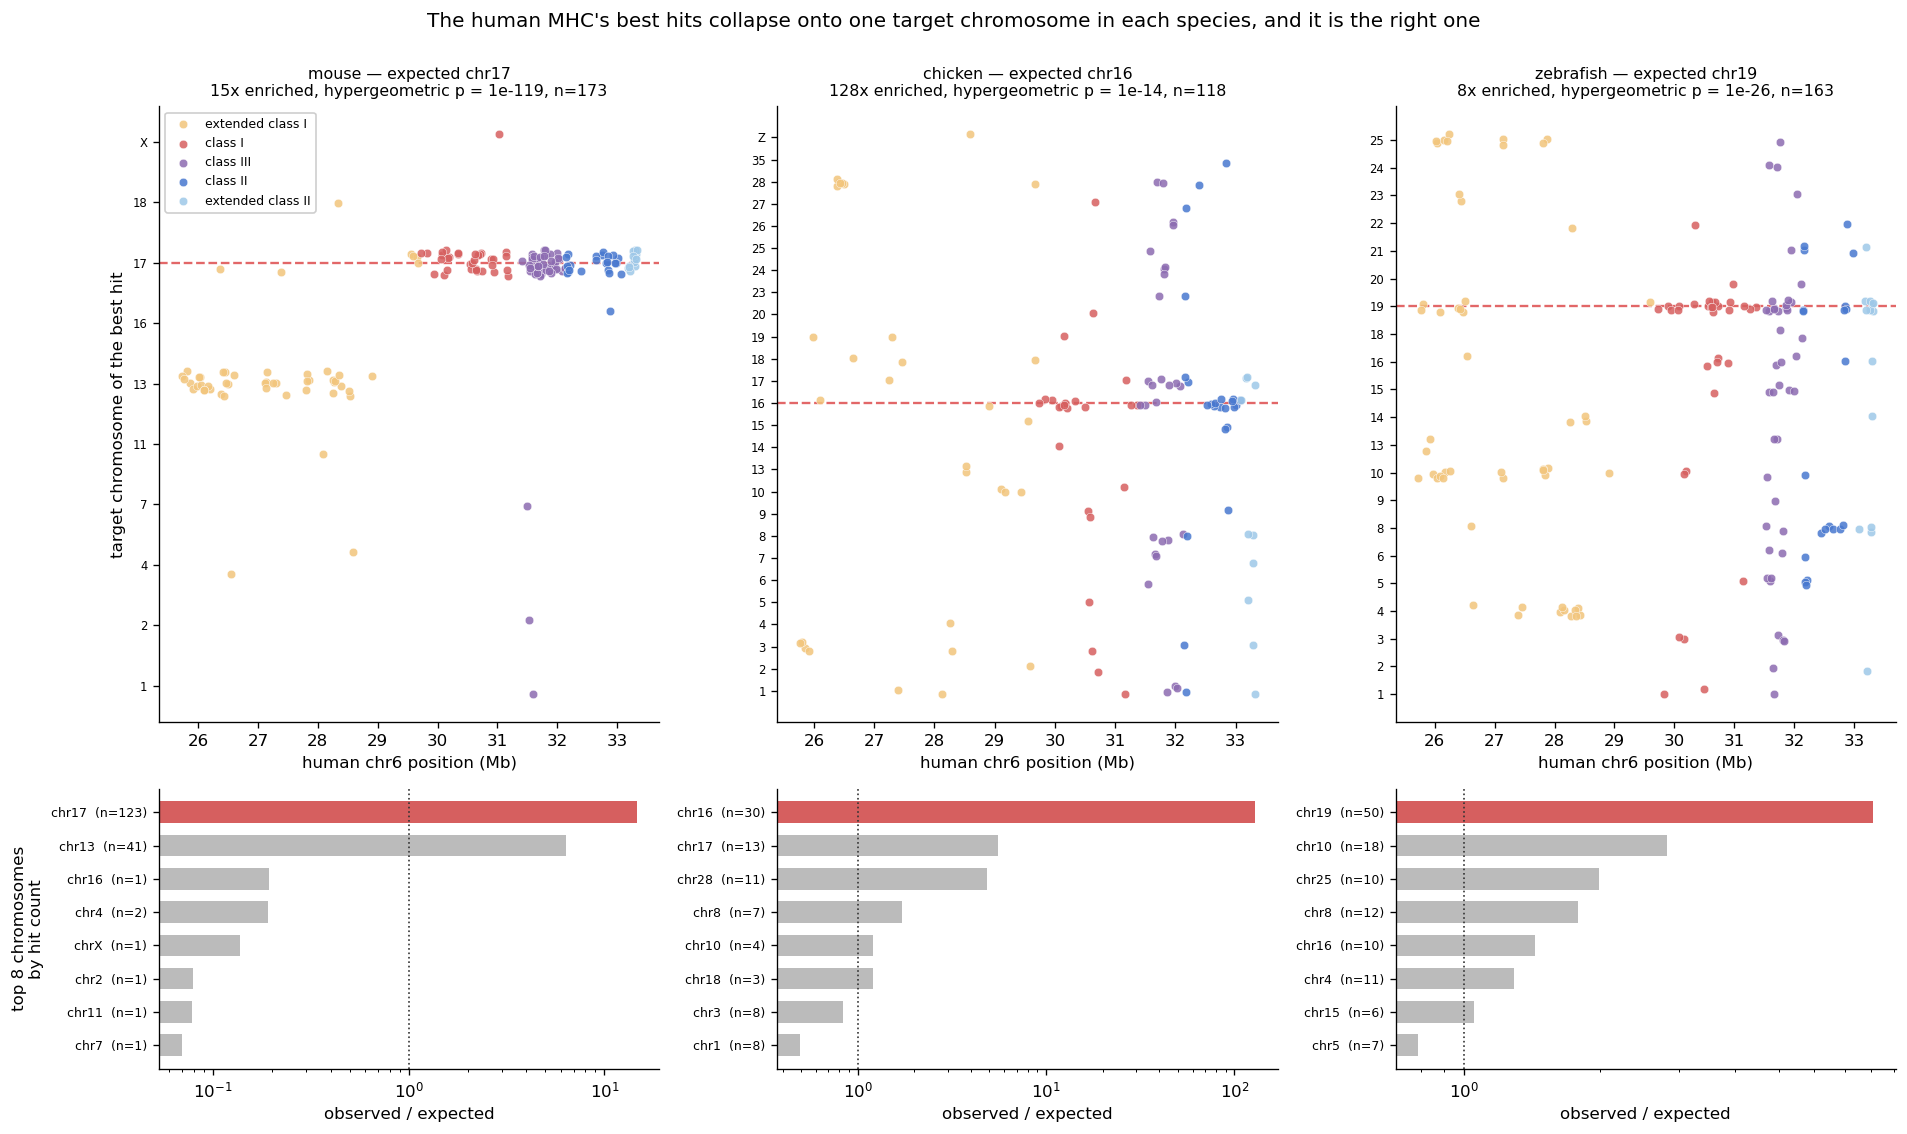

In [2]:
def chrom_sort_key(c):
    # Numeric chromosomes in order, then W/X/Y/Z/MT and scaffolds, so the axis reads
    # like a karyotype rather than like a string sort ("10" before "2").
    return (0, int(c)) if c.isdigit() else (1, 0)


per_chrom = {}
for sp in SPECIES:
    p = placed[sp]
    null = chrom_null(sp)
    obs = p.group_by("chrom").len().rename({"len": "n_hits"})
    # Cross-join style zero-fill: every chromosome carrying a placeable protein is a
    # chromosome a hit could have landed on, so it belongs in the table with n_hits 0.
    t = (
        null.join(obs, on="chrom", how="left")
        .with_columns(pl.col("n_hits").fill_null(0))
        .with_columns(obs_share=pl.col("n_hits") / p.height)
        .with_columns(enrichment=pl.col("obs_share") / pl.col("share"))
        .with_columns(is_mhc=pl.col("chrom") == mu.MHC_LOCUS[sp][0])
        .sort("n_hits", descending=True)
    )
    per_chrom[sp] = t

print(
    "Top target chromosomes per species, with the chromosome's own share as the null:"
)
for sp in SPECIES:
    t = (
        per_chrom[sp]
        .head(5)
        .with_columns(
            share=pl.col("share").round(4),
            obs_share=pl.col("obs_share").round(3),
            enrichment=pl.col("enrichment").round(1),
        )
    )
    print(f"\n{sp}  (expected chr{mu.MHC_LOCUS[sp][0]}, {mu.MHC_LOCUS[sp][1]})")
    with pl.Config(tbl_rows=10, tbl_width_chars=170):
        print(t)

fig, axes = plt.subplots(
    2, 3, figsize=(16, 9.4), gridspec_kw={"height_ratios": [2.2, 1.0]}
)
rng = np.random.default_rng(1)
for j, sp in enumerate(SPECIES):
    ax = axes[0, j]
    p = placed[sp]
    chroms = sorted(p["chrom"].unique().to_list(), key=chrom_sort_key)
    ypos = {c: i for i, c in enumerate(chroms)}
    for name in mu.MHC_SUBREGION_ORDER:
        s = p.filter(pl.col("mhc_subregion") == name)
        if s.height == 0:
            continue
        ax.scatter(
            s["human_pos"].to_numpy() / 1e6,
            [ypos[c] + rng.uniform(-0.22, 0.22) for c in s["chrom"]],
            s=26,
            color=mu.MHC_SUBREGION_COLORS[name],
            alpha=0.85,
            edgecolor="white",
            linewidth=0.3,
            label=name if sp == "mouse" else None,
        )
    exp = mu.MHC_LOCUS[sp][0]
    if exp in ypos:
        ax.axhline(ypos[exp], color="#D62728", lw=1.4, ls="--", alpha=0.7, zorder=0)
    ax.set_yticks(range(len(chroms)))
    ax.set_yticklabels(chroms, fontsize=7)
    r = enr.filter(pl.col("species") == sp).to_dicts()[0]
    ax.set_title(
        f"{sp} — expected chr{exp}\n{r['enrichment']:.0f}x enriched, "
        f"hypergeometric p = 1e{r['log10_p_hypergeom']:.0f}, n={r['n_hits']}",
        fontsize=9.5,
    )
    ax.set_xlabel("human chr6 position (Mb)")

    ax = axes[1, j]
    t = per_chrom[sp].head(8).sort("enrichment")
    yy = np.arange(t.height)
    ax.barh(
        yy,
        t["enrichment"],
        0.65,
        color=["#D65F5F" if m else "#bbbbbb" for m in t["is_mhc"]],
    )
    ax.axvline(1.0, color="#333333", lw=1.0, ls=":")
    ax.set_yticks(yy)
    ax.set_yticklabels(
        [f"chr{c}  (n={n})" for c, n in zip(t["chrom"], t["n_hits"])], fontsize=7.5
    )
    ax.set_xscale("log")
    ax.set_xlabel("observed / expected")
axes[0, 0].set_ylabel("target chromosome of the best hit")
axes[0, 0].legend(fontsize=7.5, loc="upper left", framealpha=0.95)
axes[1, 0].set_ylabel("top 8 chromosomes\nby hit count")
for ax in axes.ravel():
    for s_ in ("right", "top"):
        ax.spines[s_].set_visible(False)
fig.suptitle(
    "The human MHC's best hits collapse onto one target chromosome in each species, "
    "and it is the right one",
    y=1.0,
)
fig.tight_layout()
fig.savefig(FIG_DIR / "222_mhc_target_chromosome.png", dpi=200)

## 2. Inside the block: is the gene order conserved?

Landing on the right chromosome is the weak version of synteny. The strong version is
**collinearity** — human gene order preserved in the target. Restricting to the top-hit
chromosome and correlating human rank position with target rank position, conserved order
shows up as a large |ρ| and an inversion shows up as a negative sign.

The sign is block orientation and says nothing about strength, so the text reports **|ρ|**
and the interval. Mouse gives |ρ| = 0.91 across 123 genes with a 95% confidence interval
that does not come near zero: order conserved, orientation inverted, which is the expected
relationship between human chr6p21 and mouse chr17.

Chicken and zebrafish are the honest part. Both point estimates are near zero, but at n=30
and n=50 the Fisher-z intervals reach past ±0.35, which includes moderate collinearity in
either direction. The claim those two support is **no detectable collinearity at this n**,
not "the order is shuffled". Distinguishing the two would need more genes on the block, not
a different statistic.

Collinearity on the top-hit chromosome (Spearman, Fisher-z 95% CI):
shape: (3, 9)
┌───────────┬───────┬─────────┬──────────────┬───┬────────┬────────┬────────────┬──────────────────┐
│ species   ┆ chrom ┆ n_genes ┆ spearman_rho ┆ … ┆ ci_lo  ┆ ci_hi  ┆ p_value    ┆ ci_excludes_zero │
│ ---       ┆ ---   ┆ ---     ┆ ---          ┆   ┆ ---    ┆ ---    ┆ ---        ┆ ---              │
│ str       ┆ str   ┆ i64     ┆ f64          ┆   ┆ f64    ┆ f64    ┆ f64        ┆ bool             │
╞═══════════╪═══════╪═════════╪══════════════╪═══╪════════╪════════╪════════════╪══════════════════╡
│ mouse     ┆ 17    ┆ 123     ┆ -0.914       ┆ … ┆ -0.939 ┆ -0.879 ┆ 3.3533e-49 ┆ true             │
│ chicken   ┆ 16    ┆ 30      ┆ 0.002        ┆ … ┆ -0.358 ┆ 0.362  ┆ 0.990496   ┆ false            │
│ zebrafish ┆ 19    ┆ 50      ┆ -0.124       ┆ … ┆ -0.389 ┆ 0.16   ┆ 0.391916   ┆ false            │
└───────────┴───────┴─────────┴──────────────┴───┴────────┴────────┴────────────┴──────────────────┘
mouse    

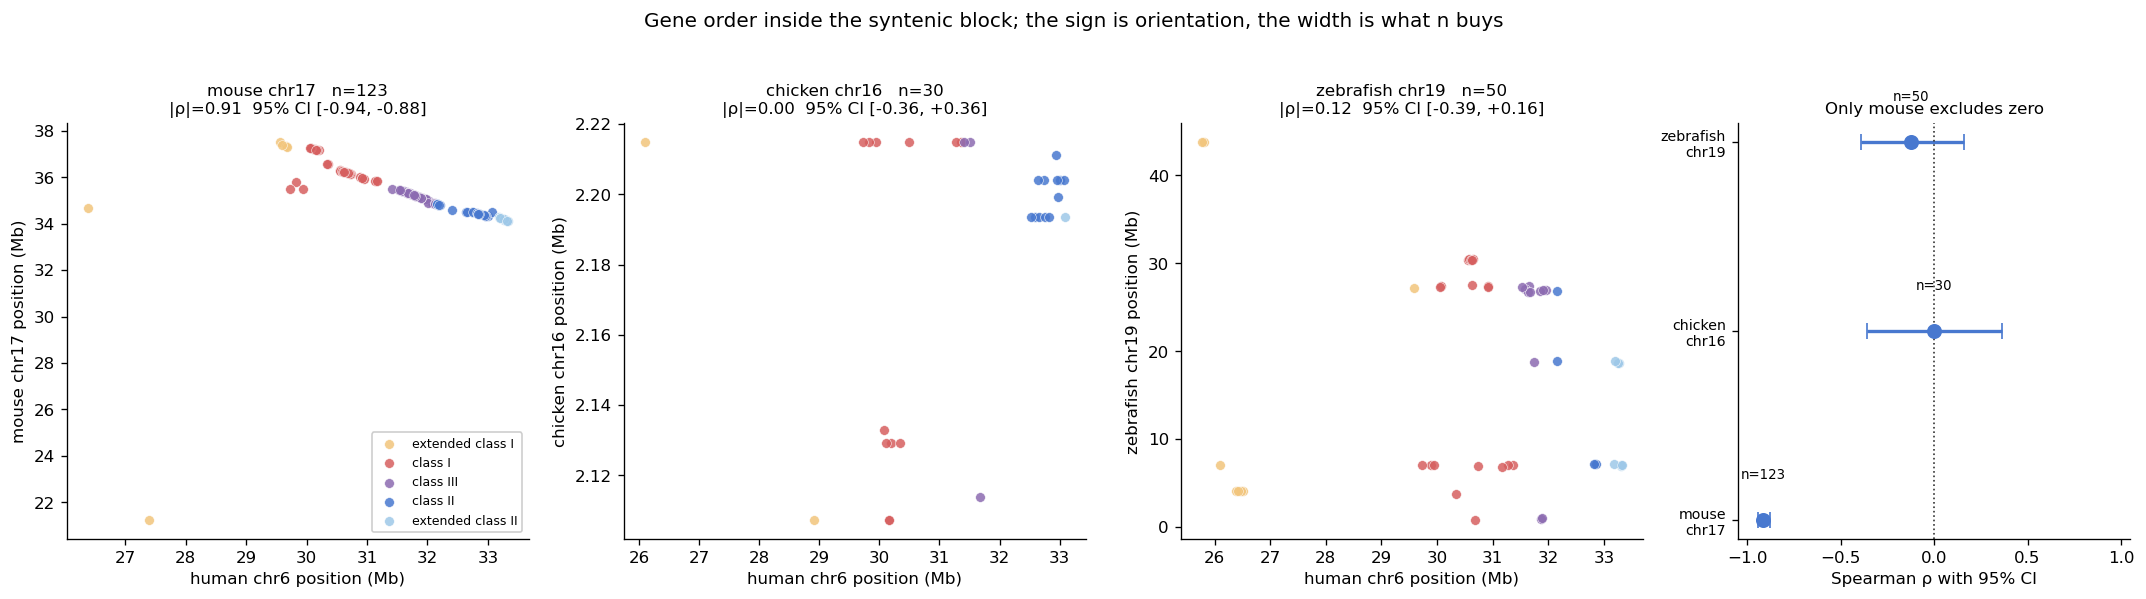

In [3]:
def fisher_ci(rho, n, alpha=0.05):
    # Fisher z transform. Undefined for n <= 3 or |rho| == 1, both of which are returned as
    # nulls rather than as an interval that does not exist.
    if n <= 3 or not np.isfinite(rho) or abs(rho) >= 1.0:
        return (float("nan"), float("nan"))
    z = np.arctanh(rho)
    se = 1.0 / np.sqrt(n - 3)
    crit = 1.959963984540054
    return (float(np.tanh(z - crit * se)), float(np.tanh(z + crit * se)))


fig, axes = plt.subplots(
    1, 4, figsize=(18, 4.8), gridspec_kw={"width_ratios": [1, 1, 1, 0.85]}
)
stats = []
for ax, sp in zip(axes[:3], SPECIES):
    p = placed[sp]
    top_chrom = per_chrom[sp]["chrom"][0]
    s = p.filter(pl.col("chrom") == top_chrom)
    for name in mu.MHC_SUBREGION_ORDER:
        sub = s.filter(pl.col("mhc_subregion") == name)
        if sub.height == 0:
            continue
        ax.scatter(
            sub["human_pos"].to_numpy() / 1e6,
            sub["midpoint"].to_numpy() / 1e6,
            s=34,
            color=mu.MHC_SUBREGION_COLORS[name],
            alpha=0.85,
            edgecolor="white",
            linewidth=0.35,
            label=name if sp == "mouse" else None,
        )
    hx = s["human_pos"].to_numpy().astype(float)
    ty = s["midpoint"].to_numpy().astype(float)
    if len(hx) > 2:
        rho, pv = spearmanr(hx, ty)
    else:
        rho, pv = float("nan"), float("nan")
    lo, hi = fisher_ci(rho, len(hx))
    stats.append(
        {
            "species": sp,
            "chrom": top_chrom,
            "n_genes": len(hx),
            "spearman_rho": round(float(rho), 3),
            "abs_rho": round(abs(float(rho)), 3),
            "ci_lo": round(lo, 3),
            "ci_hi": round(hi, 3),
            "p_value": float(pv),
            "ci_excludes_zero": bool(lo * hi > 0),
        }
    )
    ax.set_title(
        f"{sp} chr{top_chrom}   n={len(hx)}\n|ρ|={abs(rho):.2f}  "
        f"95% CI [{lo:+.2f}, {hi:+.2f}]",
        fontsize=10,
    )
    ax.set_xlabel("human chr6 position (Mb)")
    ax.set_ylabel(f"{sp} chr{top_chrom} position (Mb)")

coll = pl.DataFrame(stats)
print("Collinearity on the top-hit chromosome (Spearman, Fisher-z 95% CI):")
with pl.Config(tbl_width_chars=190, tbl_rows=10):
    print(coll)
for r in coll.iter_rows(named=True):
    verdict = (
        "collinear, orientation " + ("inverted" if r["spearman_rho"] < 0 else "same")
        if r["ci_excludes_zero"]
        else "no detectable collinearity at this n"
    )
    print(
        f"{r['species']:10s} chr{r['chrom']:<3s} n={r['n_genes']:3d}  "
        f"|ρ|={r['abs_rho']:.3f}  CI [{r['ci_lo']:+.3f}, {r['ci_hi']:+.3f}]  "
        f"p={r['p_value']:.2e}  -> {verdict}"
    )

ax = axes[3]
yy = np.arange(coll.height)
ax.errorbar(
    coll["spearman_rho"],
    yy,
    xerr=[coll["spearman_rho"] - coll["ci_lo"], coll["ci_hi"] - coll["spearman_rho"]],
    fmt="o",
    ms=8,
    lw=2,
    capsize=5,
    color="#4878CF",
)
ax.axvline(0, color="#333333", lw=1.0, ls=":")
for i, r in enumerate(coll.iter_rows(named=True)):
    ax.text(r["spearman_rho"], i + 0.22, f"n={r['n_genes']}", ha="center", fontsize=8)
ax.set_yticks(yy)
ax.set_yticklabels(
    [f"{r['species']}\nchr{r['chrom']}" for r in coll.iter_rows(named=True)],
    fontsize=8.5,
)
ax.set_xlim(-1.05, 1.05)
ax.set_xlabel("Spearman ρ with 95% CI")
ax.set_title("Only mouse excludes zero", fontsize=10)
axes[0].legend(fontsize=7.5, loc="best", framealpha=0.95)
for a_ in axes:
    for s_ in ("right", "top"):
        a_.spines[s_].set_visible(False)
fig.suptitle(
    "Gene order inside the syntenic block; the sign is orientation, the width is "
    "what n buys",
    y=1.03,
)
fig.tight_layout()
fig.savefig(FIG_DIR / "222_mhc_collinearity.png", dpi=200)

## 3. The curated MHC genes, gene by gene

The 24 genes named individually, which is where the three species stop agreeing.

Mouse should put everything in H2 on chromosome 17. Chicken should put everything in the B
locus on 16. Zebrafish should split: the class I core sits on chromosome 19 and the class II
genes are somewhere else entirely — the region did not stay together in teleosts. That split
is the single most striking thing about MHC evolution outside mammals, and if the run
reproduces it, the hits are tracking real loci rather than sequence similarity alone.

These three facts are the notebook's actual product. They are what make the pipeline's
outputs trustworthy enough to argue with, which is the argument 223 needs.

Best phmmer hit for each curated MHC gene, with its target locus:
shape: (24, 5)
┌───────────────────┬─────────────┬───────────────┬─────────────┬────────────────────────┐
│ mhc_class         ┆ hgnc_symbol ┆ mouse         ┆ chicken     ┆ zebrafish              │
│ ---               ┆ ---         ┆ ---           ┆ ---         ┆ ---                    │
│ str               ┆ str         ┆ str           ┆ str         ┆ str                    │
╞═══════════════════╪═════════════╪═══════════════╪═════════════╪════════════════════════╡
│ I classical       ┆ HLA-A       ┆ chr17 H2-D1   ┆ chr16 BF1   ┆ chr19 mhc1uba          │
│ I classical       ┆ HLA-B       ┆ null          ┆ chr16 BF1   ┆ chr19 mhc1uba          │
│ I classical       ┆ HLA-C       ┆ null          ┆ chr16 BF1   ┆ chr19 mhc1uba          │
│ I non-classical   ┆ HLA-E       ┆ null          ┆ chr16 BF1   ┆ chr1 mhc1zba           │
│ I non-classical   ┆ HLA-F       ┆ chr17 H2-D1   ┆ chr16 BF1   ┆ chr19 mhc1uba          │
│ I non-c

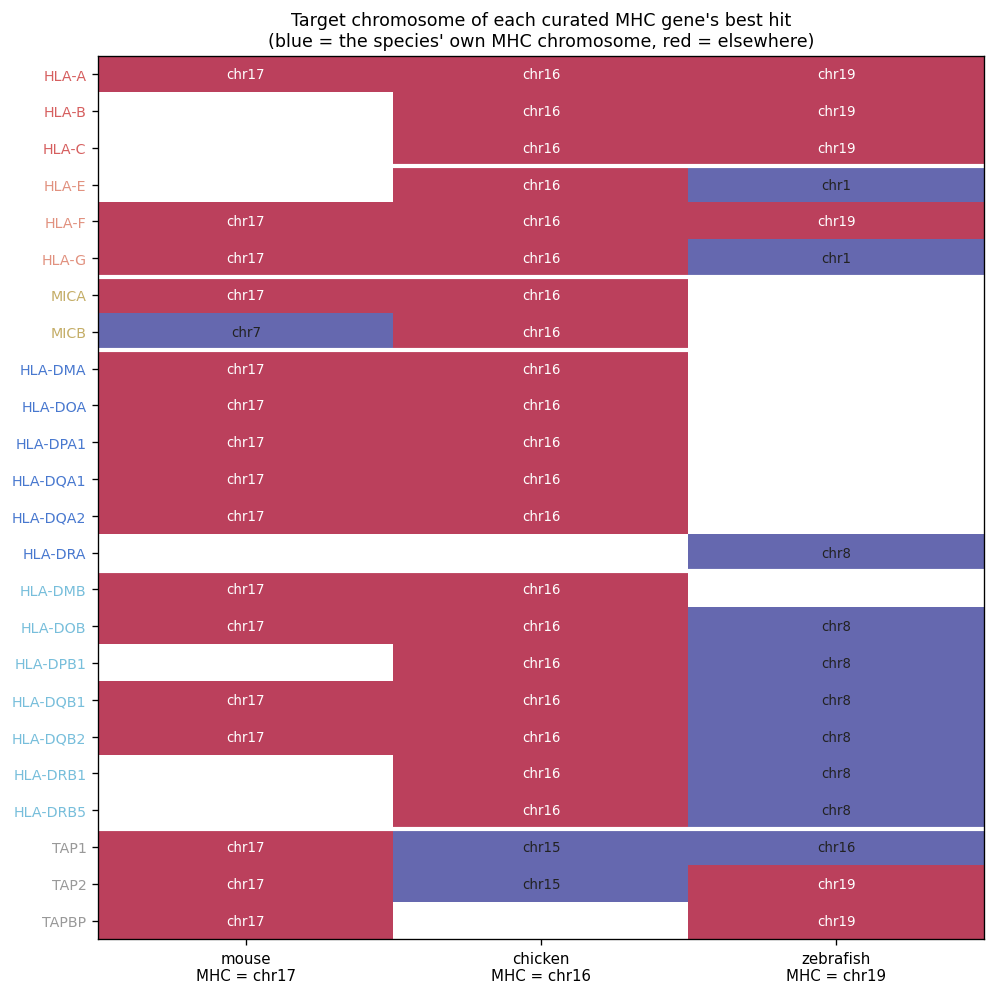

In [4]:
rows = []
for sp in SPECIES:
    p = best_baseline_hits(sp).join(CORE, on="query_acc", how="inner")
    for r in p.iter_rows(named=True):
        rows.append(
            {
                "species": sp,
                "hgnc_symbol": r["hgnc_symbol"],
                "mhc_class": r["mhc_class"],
                "target_gene": r["gene_symbol"],
                "chrom": r["chrom"],
                "pos_mb": round(r["midpoint"] / 1e6, 2),
            }
        )
detail = pl.DataFrame(rows)
wide = detail.with_columns(
    cell=pl.lit("chr") + pl.col("chrom") + pl.lit(" ") + pl.col("target_gene")
).pivot(on="species", index=["mhc_class", "hgnc_symbol"], values="cell")
korder = {c: i for i, c in enumerate(mu.MHC_CLASS_ORDER)}
wide = (
    wide.with_columns(k=pl.col("mhc_class").replace_strict(korder, default=99))
    .sort("k", "hgnc_symbol")
    .drop("k")
)
print("Best phmmer hit for each curated MHC gene, with its target locus:")
with pl.Config(tbl_rows=30, tbl_width_chars=190, fmt_str_lengths=30):
    print(wide)

print("\nTarget chromosome by MHC class:")
with pl.Config(tbl_rows=40, tbl_width_chars=170):
    print(
        detail.group_by("species", "mhc_class", "chrom")
        .len()
        .sort("species", "mhc_class", "len", descending=[False, False, True])
    )

hit_rate = (
    detail.with_columns(
        on_mhc=pl.col("chrom")
        == pl.col("species").replace_strict({sp: mu.MHC_LOCUS[sp][0] for sp in SPECIES})
    )
    .group_by("species")
    .agg(n=pl.len(), on_mhc=pl.col("on_mhc").sum())
)
print("\nCurated MHC genes landing on the species' own MHC chromosome:")
with pl.Config(tbl_width_chars=140):
    print(hit_rate.sort("species"))

genes = (
    detail.select("hgnc_symbol", "mhc_class")
    .unique()
    .with_columns(k=pl.col("mhc_class").replace_strict(korder, default=99))
    .sort("k", "hgnc_symbol")
)
glist = genes["hgnc_symbol"].to_list()
klass = dict(zip(genes["hgnc_symbol"], genes["mhc_class"]))

fig, ax = plt.subplots(figsize=(8.4, 8.4))
mat = np.full((len(glist), len(SPECIES)), np.nan)
for i, g in enumerate(glist):
    for j, sp in enumerate(SPECIES):
        r = detail.filter((pl.col("hgnc_symbol") == g) & (pl.col("species") == sp))
        if r.height == 0:
            continue
        mat[i, j] = 1.0 if r["chrom"][0] == mu.MHC_LOCUS[sp][0] else 0.0
        ax.text(
            j,
            i,
            f"chr{r['chrom'][0]}",
            ha="center",
            va="center",
            fontsize=8,
            color="white" if mat[i, j] == 1.0 else "#222222",
        )
ax.imshow(mat, cmap="RdYlBu_r", vmin=0, vmax=1, aspect="auto", alpha=0.75)
ax.set_xticks(range(len(SPECIES)))
ax.set_xticklabels(
    [f"{sp}\nMHC = chr{mu.MHC_LOCUS[sp][0]}" for sp in SPECIES], fontsize=9
)
ax.set_yticks(range(len(glist)))
ax.set_yticklabels(glist, fontsize=8.5)
for t, g in zip(ax.get_yticklabels(), glist):
    t.set_color(mu.MHC_CLASS_COLORS.get(klass[g], "#333333"))
prev = None
for i, g in enumerate(glist):
    if klass[g] != prev:
        if prev is not None:
            ax.axhline(i - 0.5, color="white", lw=2.5)
        prev = klass[g]
ax.set_title(
    "Target chromosome of each curated MHC gene's best hit\n"
    "(blue = the species' own MHC chromosome, red = elsewhere)",
    fontsize=10.5,
)
fig.tight_layout()
fig.savefig(FIG_DIR / "222_per_gene_target_chromosome.png", dpi=200)

## 4. kmerseek's divergence limit, measured on purpose

Everything above uses phmmer. This section measures where kmerseek's own signal stops, on
two different axes, because the two answers are far apart and the distance between them is
the interesting number.

**Locus identity** — does the best hit land on the right chromosome — is tested here on the
enrichment scale, with the same null as §1. Only the three Ensembl species have coordinates,
so this axis is bounded at 430 Mya by what is on disk rather than by where the signal fails.

**Family identity** — is a domain call still made and scored — comes from
[221](./221_mhc_cross_species_detection_depth.ipynb) and runs the full nine-species panel out
to 2,000 Mya.

The claim to test is that HP patterning carries locus identity to roughly 100 Myr and family
identity much further. The numbers below say where each one actually stops.

kmerseek hp_pbotc_1st_ed2 k=19, locus identity on the enrichment scale:
mouse      ( 100 Mya) chr17    87/143 hits vs  4.87% expected ->   12.5x;  distinct  84/129 ->  13.4x, hypergeometric p = 2.3e-78
chicken    ( 300 Mya) chr16     1/ 87 hits vs  0.20% expected ->    5.8x;  distinct   1/ 79 ->   6.4x, hypergeometric p = 1.5e-01
zebrafish  ( 430 Mya) chr19    15/134 hits vs  3.78% expected ->    3.0x;  distinct  15/ 97 ->   4.1x, hypergeometric p = 3.5e-06

phmmer on the same scale, for reference:
mouse      ( 100 Mya)   15.5x  p = 6.7e-120
chicken    ( 300 Mya)   59.9x  p = 1.3e-14
zebrafish  ( 430 Mya)    8.6x  p = 9.7e-27

Agreement with phmmer on the target chromosome, per query:
shape: (3, 4)
┌───────────┬─────────────────────┬──────────────────────┬───────────┐
│ species   ┆ queries_both_placed ┆ same_chrom_as_phmmer ┆ agreement │
│ ---       ┆ ---                 ┆ ---                  ┆ ---       │
│ str       ┆ i64                 ┆ i64                  ┆ f64       │
╞═══════

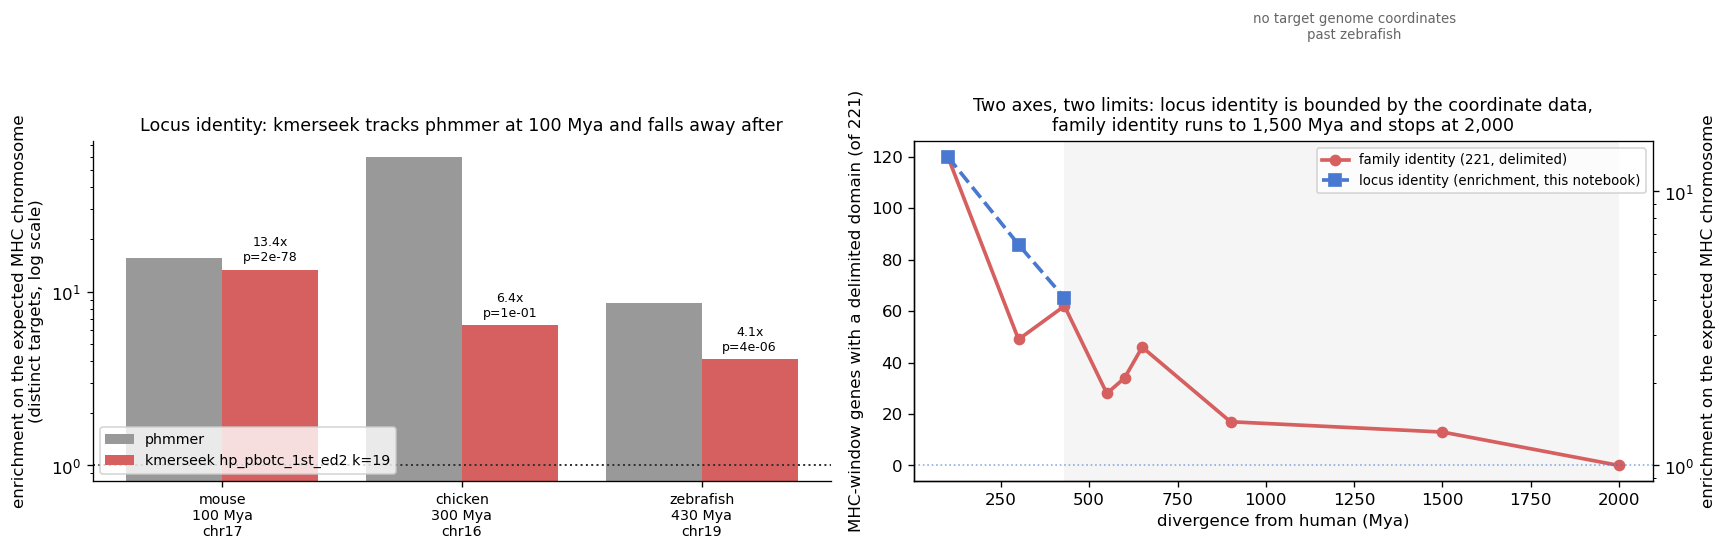

In [5]:
ARM = ("hp_pbotc_1st_ed2", 19)
ks = (
    pl.scan_parquet(mu.KMERSEEK_REGIONS)
    .filter(
        (pl.col("alphabet") == ARM[0])
        & (pl.col("ksize") == ARM[1])
        & pl.col("species").is_in(SPECIES)
    )
    .select("query_acc", "target_name", "species", "containment", "max_containment")
    .collect()
    .with_columns(target_acc=mu.uniprot_acc(pl.col("target_name")))
)

ks_placed, ks_rows, agree_rows = {}, [], []
for sp in SPECIES:
    k = (
        ks.filter(pl.col("species") == sp)
        .sort("max_containment", descending=True)
        .group_by("query_acc")
        .head(1)
        .join(LOCI[sp], on="target_acc", how="inner")
        .join(HUMAN, on="query_acc", how="inner")
    )
    ks_placed[sp] = k
    ks_rows.append(enrichment(k, sp, mu.MHC_LOCUS[sp][0]))
    shared = k.select("query_acc", k_chrom="chrom").join(
        placed[sp].select("query_acc", p_chrom="chrom"), on="query_acc", how="inner"
    )
    n_agree = shared.filter(pl.col("k_chrom") == pl.col("p_chrom")).height
    agree_rows.append(
        {
            "species": sp,
            "queries_both_placed": shared.height,
            "same_chrom_as_phmmer": n_agree,
            "agreement": round(n_agree / shared.height, 3) if shared.height else None,
        }
    )
ks_enr = pl.DataFrame(ks_rows)
agree = pl.DataFrame(agree_rows)

print(f"kmerseek {ARM[0]} k={ARM[1]}, locus identity on the enrichment scale:")
for r in ks_enr.iter_rows(named=True):
    print(
        f"{r['species']:10s} ({r['mya']:4d} Mya) chr{r['chrom']:<3s}  "
        f"{r['n_hits_on_chrom']:3d}/{r['n_hits']:3d} hits vs "
        f"{100 * r['expected_share']:5.2f}% expected -> {r['enrichment']:6.1f}x;  "
        f"distinct {r['n_distinct_on_chrom']:3d}/{r['n_distinct_targets']:3d} -> "
        f"{r['enrichment_distinct']:5.1f}x, hypergeometric p = "
        f"{10 ** r['log10_p_hypergeom']:.1e}"
    )
print("\nphmmer on the same scale, for reference:")
for r in enr.iter_rows(named=True):
    print(
        f"{r['species']:10s} ({r['mya']:4d} Mya) {r['enrichment_distinct']:6.1f}x  "
        f"p = {10 ** r['log10_p_hypergeom']:.1e}"
    )
print("\nAgreement with phmmer on the target chromosome, per query:")
with pl.Config(tbl_width_chars=170):
    print(agree)

# Family identity comes from the gene-level table, best kmerseek arm per species, on the
# same `delimited` definition 221 uses. Zero-filled over the nine-species grid.
gl = mu.load_gene_level().with_columns(arm=pl.col("tool") + "." + pl.col("variant"))
kgl = (
    gl.filter((pl.col("tool") == "kmerseek") & (pl.col("n_tp") > 0))
    .group_by("arm", "species")
    .agg(pl.col("query_acc").n_unique().alias("n"))
)
fam_reach = (
    pl.DataFrame({"species": mu.SPECIES_ORDER})
    .join(
        kgl.group_by("species").agg(pl.col("n").max().alias("n_genes")),
        on="species",
        how="left",
    )
    .with_columns(
        pl.col("n_genes").fill_null(0),
        mya=pl.col("species").replace_strict(mu.SPECIES_MYA),
    )
    .sort("mya")
)
print(
    f"\nkmerseek family identity: MHC-window genes (of {window.height}) with a delimited "
    "domain, best arm per species:"
)
with pl.Config(tbl_rows=12, tbl_width_chars=140):
    print(fam_reach)
last_nonzero = fam_reach.filter(pl.col("n_genes") > 0).sort("mya")
print(
    f"family identity holds to {last_nonzero['mya'][-1]} Mya "
    f"({last_nonzero['species'][-1]}, {last_nonzero['n_genes'][-1]} genes) and is zero at "
    f"{fam_reach['mya'][-1]} Mya ({fam_reach['species'][-1]})"
)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.0))
ax = axes[0]
x = np.arange(len(SPECIES))
ax.bar(x - 0.2, enr["enrichment_distinct"], 0.4, color="#999999", label="phmmer")
ax.bar(
    x + 0.2,
    ks_enr["enrichment_distinct"],
    0.4,
    color=mu.TOOL_FAMILY_COLORS["kmerseek"],
    label=f"kmerseek {ARM[0]} k={ARM[1]}",
)
ax.axhline(1.0, color="#333333", lw=1.2, ls=":")
for i in range(len(SPECIES)):
    r = ks_enr.to_dicts()[i]
    p = 10 ** r["log10_p_hypergeom"]
    ax.text(
        i + 0.2,
        r["enrichment_distinct"] * 1.12,
        f"{r['enrichment_distinct']:.1f}x\np={p:.0e}",
        ha="center",
        fontsize=7.5,
    )
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{sp}\n{mu.SPECIES_MYA[sp]} Mya\nchr{mu.MHC_LOCUS[sp][0]}" for sp in SPECIES],
    fontsize=8.5,
)
ax.set_ylabel(
    "enrichment on the expected MHC chromosome\n(distinct targets, log scale)"
)
ax.set_title(
    "Locus identity: kmerseek tracks phmmer at 100 Mya and falls away after",
    fontsize=10.5,
)
ax.legend(fontsize=8.5, loc="lower left")

ax = axes[1]
xm = np.array([mu.SPECIES_MYA[s] for s in mu.SPECIES_ORDER], dtype=float)
ax.plot(
    xm,
    fam_reach["n_genes"],
    marker="o",
    ms=6,
    lw=2.2,
    color=mu.TOOL_FAMILY_COLORS["kmerseek"],
    label="family identity (221, delimited)",
)
ax.set_xlabel("divergence from human (Mya)")
ax.set_ylabel(f"MHC-window genes with a delimited domain (of {window.height})")
ax2 = ax.twinx()
xl = np.array([mu.SPECIES_MYA[s] for s in SPECIES], dtype=float)
ax2.plot(
    xl,
    ks_enr["enrichment_distinct"],
    marker="s",
    ms=7,
    lw=2.2,
    ls="--",
    color="#4878CF",
    label="locus identity (enrichment, this notebook)",
)
ax2.set_yscale("log")
ax2.set_ylabel("enrichment on the expected MHC chromosome")
ax2.axhline(1.0, color="#4878CF", lw=1.0, ls=":", alpha=0.6)
ax.axvspan(430, 2000, color="#000000", alpha=0.04, lw=0)
ax.text(
    1250,
    window.height * 0.75,
    "no target genome coordinates\npast zebrafish",
    ha="center",
    fontsize=8,
    color="#666666",
)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper right")
ax.set_title(
    "Two axes, two limits: locus identity is bounded by the coordinate data,\n"
    "family identity runs to 1,500 Mya and stops at 2,000",
    fontsize=10.5,
)
for a_ in (axes[0], ax):
    for s_ in ("right", "top"):
        a_.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "222_kmerseek_vs_phmmer_synteny.png", dpi=200)

## Summary

mouse      chr17  123/173 = 71.1% (expected  4.87%)  query-level   14.6x binomial p = 2.8e-119  |  distinct targets 115/152  15.5x hypergeometric p = 6.7e-120
chicken    chr16   30/118 = 25.4% (expected  0.20%)  query-level  128.5x binomial p = 6.2e-54  |  distinct targets   9/ 76  59.9x hypergeometric p = 1.3e-14
zebrafish  chr19   50/163 = 30.7% (expected  3.78%)  query-level    8.1x binomial p = 3.3e-31  |  distinct targets  40/123   8.6x hypergeometric p = 9.7e-27
ranked by query-level enrichment    : ['chicken', 'mouse', 'zebrafish']
ranked by distinct-target enrichment: ['chicken', 'mouse', 'zebrafish']
ranked by weight of evidence (p)    : ['mouse', 'zebrafish', 'chicken']

zebrafish, curated MHC genes by class and chromosome:
shape: (7, 3)
┌───────────────────┬───────┬─────┐
│ mhc_class         ┆ chrom ┆ len │
│ ---               ┆ ---   ┆ --- │
│ str               ┆ str   ┆ u32 │
╞═══════════════════╪═══════╪═════╡
│ I classical       ┆ 19    ┆ 3   │
│ I non-classical   ┆ 1   

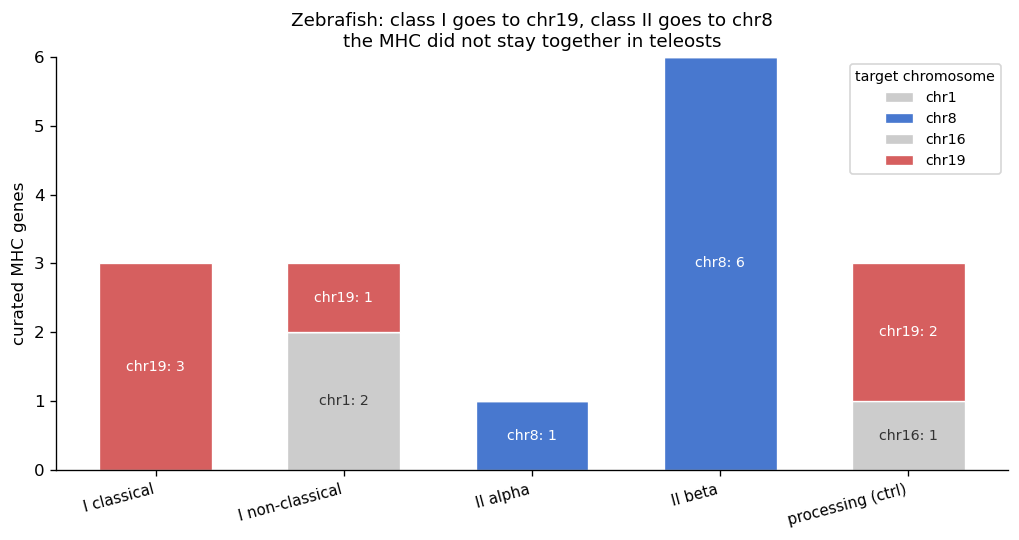

In [6]:
for r in enr.iter_rows(named=True):
    print(
        f"{r['species']:10s} chr{r['chrom']:<3s} "
        f"{r['n_hits_on_chrom']:3d}/{r['n_hits']:3d} = {100 * r['obs_share']:4.1f}% "
        f"(expected {100 * r['expected_share']:5.2f}%)  query-level {r['enrichment']:6.1f}x "
        f"binomial p = {10 ** r['log10_p_binom']:.1e}  |  distinct targets "
        f"{r['n_distinct_on_chrom']:3d}/{r['n_distinct_targets']:3d} "
        f"{r['enrichment_distinct']:5.1f}x hypergeometric p = "
        f"{10 ** r['log10_p_hypergeom']:.1e}"
    )
rank_q = enr.sort("enrichment", descending=True)["species"].to_list()
rank_d = enr.sort("enrichment_distinct", descending=True)["species"].to_list()
rank_p = enr.sort("log10_p_hypergeom")["species"].to_list()
print(f"ranked by query-level enrichment    : {rank_q}")
print(f"ranked by distinct-target enrichment: {rank_d}")
print(f"ranked by weight of evidence (p)    : {rank_p}")

zf = best_baseline_hits("zebrafish").join(CORE, on="query_acc", how="inner")
zf_tbl = (
    zf.group_by("mhc_class", "chrom")
    .len()
    .sort("mhc_class", "len", descending=[False, True])
)
print("\nzebrafish, curated MHC genes by class and chromosome:")
with pl.Config(tbl_rows=20, tbl_width_chars=140):
    print(zf_tbl)

# The zebrafish split is the headline of this notebook, so it gets its own picture.
fig, ax = plt.subplots(figsize=(8.6, 4.6))
classes = [
    c for c in mu.MHC_CLASS_ORDER if zf_tbl.filter(pl.col("mhc_class") == c).height
]
chroms = sorted(
    zf_tbl["chrom"].unique().to_list(),
    key=lambda c: (0, int(c)) if c.isdigit() else (1, 0),
)
bottom = np.zeros(len(classes))
for ch in chroms:
    vals = [
        zf_tbl.filter((pl.col("mhc_class") == c) & (pl.col("chrom") == ch))["len"].sum()
        for c in classes
    ]
    ax.bar(
        range(len(classes)),
        vals,
        0.6,
        bottom=bottom,
        label=f"chr{ch}",
        color={"19": "#D65F5F", "8": "#4878CF"}.get(ch, "#cccccc"),
        edgecolor="white",
        linewidth=0.8,
    )
    for i, v in enumerate(vals):
        if v:
            ax.text(
                i,
                bottom[i] + v / 2,
                f"chr{ch}: {v}",
                ha="center",
                va="center",
                fontsize=8.5,
                color="white" if ch in ("19", "8") else "#333333",
            )
    bottom += np.array(vals, dtype=float)
ax.set_xticks(range(len(classes)))
ax.set_xticklabels(classes, fontsize=9, rotation=15, ha="right")
ax.set_ylabel("curated MHC genes")
ax.set_title(
    "Zebrafish: class I goes to chr19, class II goes to chr8\n"
    "the MHC did not stay together in teleosts",
    fontsize=11,
)
ax.legend(fontsize=8.5, title="target chromosome", title_fontsize=8.5)
for s_ in ("right", "top"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "222_zebrafish_class_split.png", dpi=200)

The block is there, and nothing in the scoring put it there.

**What this notebook establishes.** The domain-call pipeline reproduces three independent,
lineage-specific facts about MHC genome organisation that it was never given: the mouse H2
complex, the chicken minimal essential MHC, and the teleost class I / class II split. It does
that from sequence alone, with chromosome coordinates joined on afterwards. That is the
reason 223's argument about the IoU metric is a critique of a scoring rule rather than an
excuse for a pipeline that does not work.

**Chicken is the strongest result, not the weakest.** On raw percentage the three species
read as a decay curve — mouse 71%, zebrafish 31%, chicken 25% — and that reading is an
artefact of chromosome size. Chicken chromosome 16 is a microchromosome holding 0.20% of the
placeable proteome, so 30 of 118 hits landing there is a 128-fold enrichment; on distinct
target proteins it is 60-fold, hypergeometric p = 1e-14. Mouse chromosome 17 holds 4.87%, so
123 of 173 is 14.6-fold, 15.5-fold on distinct targets, p = 7e-120. Zebrafish chromosome 19
holds 3.78%, giving 8.1-fold and 8.6-fold, p = 1e-26. Mouse still has by far the most
evidence behind it, because it has vastly more hits; chicken has the sharpest concentration.
Two different questions, two different orderings, and neither is the raw percentage.

**Gene order survives in mouse and is untestable in the other two.** Inside the block, human
and mouse rank positions give |ρ| = 0.91 across 123 genes, 95% CI [0.88, 0.94] — order
conserved, orientation inverted, which is the expected relationship between human chr6p21 and
mouse chr17. Chicken is |ρ| = 0.00 at n=30 with CI [−0.36, +0.36] and zebrafish is |ρ| = 0.12
at n=50 with CI [−0.39, +0.16]. Both intervals include moderate collinearity in either
direction, so the correct statement is no detectable collinearity at this n, not that the
order is shuffled. Landing on the chromosome and preserving the order are different
statements, and only the first is established for all three species.

**kmerseek's two limits are 4x apart on the divergence axis.** On locus identity, hp_pbotc
k=19 puts 84 of 129 distinct mouse targets on chromosome 17 — 13.4-fold enriched,
p = 2e-78, close behind phmmer's 15.5-fold. In zebrafish it is down to 4.1-fold but still
significant at p = 4e-06. Chicken returns 6.4-fold with p = 0.15, which is not a null result:
79 placed distinct targets against a chromosome holding 0.20% of the proteome gives an
expected count of 0.16, so a single hit is the most that can be observed and it cannot clear
significance whatever the truth is. The honest reading is that locus identity is strong at
100 Mya, weaker but still detectable at 430 Mya, and untestable at 300 Mya for want of
chromosome size. On family identity, from 221, the best kmerseek arm still delimits 13 of the
221 window genes in *Arabidopsis* at 1,500 Mya and none in *E. coli* at 2,000. So the two
axes stop roughly 430 Mya and 1,500 Mya apart, both bounded by what the data can test rather
than by a clean failure point.

**The caveat that goes with all of it.** "Best hit by e-value" is not an ortholog call — it
is not reciprocal, and it has no synteny input. That is deliberate here, because it is what
makes the block meaningful, but it also means individual rows in §3 can be wrong where a
gene's closest match is a paralog. TAP1/TAP2 in chicken are the visible case: they land off
the B locus because their best hit by e-value is another ABC transporter rather than the real
TAP ortholog. The two null models in §1 exist for the same reason: several queries can pick
the same target protein, so the query-level count is a binomial and only the distinct-target
count is a hypergeometric.